In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

class Config:
    seed = 42
    test_size = 0.2
    batch_size = 64
    lr = 0.001
    weight_decay = 1e-4
    dropout_rate = 0.3
    patience = 15
    epochs = 200

torch.manual_seed(Config.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_data():
    df = pd.read_csv('encoded_scaled_df.csv', index_col=0)
    df = df.drop(['Unnamed: 0', 'Sales'], axis=1, errors='ignore')
    
    X = df.drop('Price', axis=1).values
    y = df['Price'].values.reshape(-1, 1)
    
    return X, y

X, y = load_data()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=Config.test_size, random_state=Config.seed
)

def to_tensor(data, device):
    return torch.FloatTensor(data).to(device)

X_train_tensor = to_tensor(X_train, device)
y_train_tensor = to_tensor(y_train, device)
X_test_tensor = to_tensor(X_test, device)
y_test_tensor = to_tensor(y_test, device)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=Config.batch_size)

class EnhancedPricePredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(Config.dropout_rate),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(Config.dropout_rate/2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

model = EnhancedPricePredictor(X_train.shape[1]).to(device)
optimizer = optim.AdamW(model.parameters(), 
                      lr=Config.lr, 
                      weight_decay=Config.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                               'min', 
                                               patience=5,
                                               factor=0.5,
                                               verbose=True)
criterion = nn.HuberLoss()

class EarlyStopper:
    def __init__(self):
        self.best_loss = np.inf
        self.counter = 0
        
    def check(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= Config.patience:
                return True
        return False

early_stopper = EarlyStopper()

def train_model():
    history = {'train_loss': [], 'val_loss': [], 'r2': []}
    
    for epoch in range(Config.epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        model.eval()
        val_loss = 0
        y_pred, y_true = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                val_loss += criterion(outputs, y_batch).item()
                y_pred.extend(outputs.cpu().numpy())
                y_true.extend(y_batch.cpu().numpy())
        
        train_loss /= len(train_loader)
        val_loss /= len(test_loader)
        r2 = r2_score(y_true, y_pred)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['r2'].append(r2)
        
        scheduler.step(val_loss)
        
        print(f'Epoch {epoch+1:03d} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'R² Score: {r2:.4f}')
        
        if early_stopper.check(val_loss):
            print("Early stopping triggered!")
            break
    
    return history

history = train_model()

def evaluate_model():
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_tensor).cpu().numpy()
        test_true = y_test_tensor.cpu().numpy()
        
        mae = np.mean(np.abs(test_preds - test_true))
        rmse = np.sqrt(np.mean((test_preds - test_true)**2))
        r2 = r2_score(test_true, test_preds)
        
    print(f'\nFinal Metrics:')
    print(f'MAE: {mae:.2f}')
    print(f'RMSE: {rmse:.2f}')
    print(f'R²: {r2:.4f}')

evaluate_model()

/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001 | Train Loss: 0.1466 | Val Loss: 3.7573 | R² Score: -17.3280
Epoch 002 | Train Loss: 0.1079 | Val Loss: 1.2852 | R² Score: -3.1708
Epoch 003 | Train Loss: 0.0988 | Val Loss: 0.2351 | R² Score: 0.3297
Epoch 004 | Train Loss: 0.0880 | Val Loss: 1.6862 | R² Score: -4.4251
Epoch 005 | Train Loss: 0.0848 | Val Loss: 0.3695 | R² Score: -0.2271
Epoch 006 | Train Loss: 0.0816 | Val Loss: 0.2980 | R² Score: 0.0661
Epoch 007 | Train Loss: 0.0786 | Val Loss: 15.0573 | R² Score: -239.0695
Epoch 008 | Train Loss: 0.0744 | Val Loss: 0.8437 | R² Score: -0.9723
Epoch 009 | Train Loss: 0.0732 | Val Loss: 2.7684 | R² Score: -13.7851
Epoch 010 | Train Loss: 0.0654 | Val Loss: 0.3792 | R² Score: -0.2366
Epoch 011 | Train Loss: 0.0657 | Val Loss: 0.7018 | R² Score: -0.7649
Epoch 012 | Train Loss: 0.0635 | Val Loss: 0.3424 | R² Score: -0.0970
Epoch 013 | Train Loss: 0.0612 | Val Loss: 0.2802 | R² Score: 0.1693
Epoch 014 | Train Loss: 0.0603 | Val Loss: 0.2813 | R² Score: 0.1796
Epoch 015 | Train L


Начинаем координатный спуск с шумом...
Iter 10: Улучшение R² = 0.9221
Iter 12: Улучшение R² = 0.9221
Iter 16: Улучшение R² = 0.9221
Iter 23: Улучшение R² = 0.9221
Iter 24: Улучшение R² = 0.9221
Iter 30: Улучшение R² = 0.9221
Iter 43: Улучшение R² = 0.9222
Iter 46: Улучшение R² = 0.9222
Iter 47: Улучшение R² = 0.9222
Iter 48: Улучшение R² = 0.9233
Iter 54: Улучшение R² = 0.9233
Iter 64: Улучшение R² = 0.9233
Iter 75: Улучшение R² = 0.9233
Iter 94: Улучшение R² = 0.9233
Iter 102: Улучшение R² = 0.9233
Iter 104: Улучшение R² = 0.9233
Iter 123: Улучшение R² = 0.9234
Iter 130: Улучшение R² = 0.9234
Iter 131: Улучшение R² = 0.9234
Iter 157: Улучшение R² = 0.9235
Iter 160: Улучшение R² = 0.9235
Iter 162: Улучшение R² = 0.9235
Iter 169: Улучшение R² = 0.9235
Iter 171: Улучшение R² = 0.9235
Iter 178: Улучшение R² = 0.9235
Iter 193: Улучшение R² = 0.9240
Iter 201: Улучшение R² = 0.9240
Iter 226: Улучшение R² = 0.9243
Iter 249: Улучшение R² = 0.9244
Iter 256: Улучшение R² = 0.9249
Iter 270: Улуч

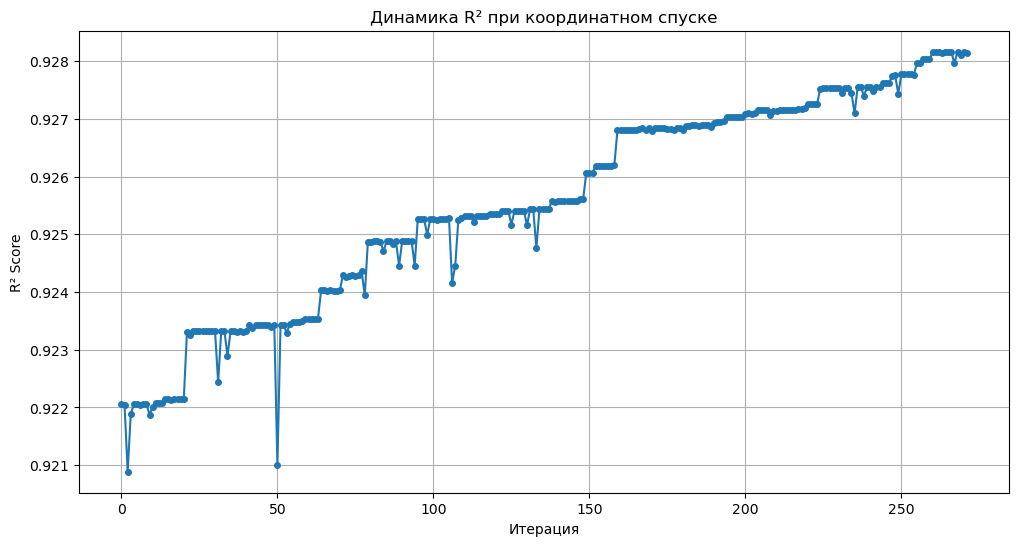


Final Metrics:
MAE: 0.16
RMSE: 0.33
R²: 0.8941


In [2]:
import matplotlib.pyplot as plt

def coordinate_descent_finetune(model, X_val, y_val, sigma=0.05, iterations=500):
    model.eval()
    best_weights = [param.clone().detach() for param in model.parameters()]
    best_r2 = r2_score(y_val.cpu().numpy(), 
                      model(X_val).cpu().detach().numpy())
    
    history_r2 = [best_r2]
    
    for i in range(iterations):
        layer_idx = np.random.randint(len(best_weights))
        param = best_weights[layer_idx]
        
        if len(param.shape) == 1:
            continue
        
        neuron = np.random.randint(param.shape[0])
        weight_idx = np.random.randint(param.shape[1])
        
        original_value = param[neuron, weight_idx].item()
        
        noise = torch.randn(1).item() * sigma
        new_value = original_value + noise
        
        new_weights = [p.clone().detach() for p in best_weights]
        new_weights[layer_idx][neuron, weight_idx] = new_value
        
        with torch.no_grad():
            for param, new_param in zip(model.parameters(), new_weights):
                param.copy_(new_param)
        
        with torch.no_grad():
            y_pred = model(X_val).cpu().numpy()
            current_r2 = r2_score(y_val.cpu().numpy(), y_pred)
        
        history_r2.append(current_r2)  # Сохраняем текущее R²
        
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_weights = new_weights
            print(f"Iter {i+1}: Улучшение R² = {best_r2:.4f}")
        else:
            new_weights[layer_idx][neuron, weight_idx] = original_value

    with torch.no_grad():
        for param, best_param in zip(model.parameters(), best_weights):
            param.copy_(best_param)
    
    return best_r2, history_r2


print("\nНачинаем координатный спуск с шумом...")
final_r2, history_r2 = coordinate_descent_finetune(
    model,
    X_train_tensor,
    y_train_tensor,
    sigma=0.01,
    iterations=1000
)

print(f"\nФинальное R² после дообучения: {final_r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(range(len(history_r2)), history_r2, marker='o', linestyle='-', markersize=4)
plt.title('Динамика R² при координатном спуске')
plt.xlabel('Итерация')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()

evaluate_model()